# 06b: CNN Development - Cloud Training (Kaggle)

**🌩️ CLOUD WORKFLOW VERSION**

This notebook is designed for **fully automated training on Kaggle's P100 GPU**.

---

## 🎯 What's Different from Notebook 06?

| Aspect | Notebook 06 (Local) | Notebook 06b (Kaggle Cloud) |
|--------|---------------------|-----------------------------|
| **Execution** | Run locally on your machine | Runs on Kaggle servers (P100 GPU) |
| **Data location** | `data/raw/images/` | `/kaggle/input/nih-chest-xrays/images/` |
| **Speed** | ~30-60 min (M2 Pro CPU) | ~3-5 min (P100 GPU) |
| **RETRAIN flag** | ✅ Yes (uses cached models) | ❌ No (always trains fresh) |
| **Interaction** | Interactive Jupyter | Headless execution via API |
| **Model storage** | `models/saved_models/` | `/kaggle/working/models/` (downloaded) |

---

## 🚀 How to Use This Notebook

### Option 1: Fully Automated (Recommended) ⭐

**One command from your terminal:**

```bash
# From project root
export KAGGLE_USERNAME="your-kaggle-username"
./scripts/kaggle_full_pipeline.sh
```

**What happens:**
1. ✅ Uploads your data splits to Kaggle (~34 MB)
2. ✅ Pushes this notebook to Kaggle
3. ✅ Kaggle starts P100 GPU execution automatically
4. ✅ Script monitors progress (polls every 30 seconds)
5. ✅ Downloads trained model when complete
6. ✅ Results saved to `models/saved_models_kaggle/`

**No browser needed. Fully headless!**

---

### Option 2: Manual Steps

#### Step 1: Upload Dataset (One-time)

```bash
export KAGGLE_USERNAME="your-username"
./scripts/kaggle_upload_dataset.sh
```

Uploads:
- `train_split.csv`, `val_split.csv`, `test_split.csv`
- `preprocessing_config.json`
- Creates Kaggle dataset: `your-username/nih-chest-xray-splits`

**Note:** Images (112K) are already on Kaggle! We only upload metadata.

#### Step 2: Train Model

```bash
./scripts/kaggle_train_headless.sh
```

This script:
- Pushes this notebook to Kaggle
- Kaggle auto-starts execution on P100 GPU
- Monitors status (polls every 30 seconds)
- Downloads results to `models/saved_models_kaggle/` when done

#### Step 3: Use Trained Model Locally

```python
import tensorflow as tf

# Load model trained on Kaggle
model = tf.keras.models.load_model(
    'models/saved_models_kaggle/cnn_custom_best.keras'
)

# Use for predictions
predictions = model.predict(X_test)
```

---

## 🔧 How Kaggle Integration Works

### 1. Dataset Linking

This notebook uses **two Kaggle datasets**:

**Dataset 1: NIH Chest X-Rays (public)**
- Already on Kaggle: `nih-chest-xrays`
- 112,120 images (~47 GB)
- Path: `/kaggle/input/nih-chest-xrays/images/`

**Dataset 2: Your Data Splits (private)**
- Created by you: `your-username/nih-chest-xray-splits`
- CSVs + metadata (~34 MB)
- Path: `/kaggle/input/nih-chest-xray-splits/`

The `kernel-metadata.json` (created by `kaggle_train_headless.sh`) links both:

```json
{
  "id": "your-username/cnn-development-cloud",
  "title": "CNN Development (Cloud)",
  "code_file": "06b_cnn_kaggle.ipynb",
  "language": "python",
  "kernel_type": "notebook",
  "is_private": true,
  "enable_gpu": true,
  "enable_internet": false,
  "dataset_sources": [
    "nih-chest-xrays",
    "your-username/nih-chest-xray-splits"
  ]
}
```

### 2. Path Conversion

Your local CSVs have paths like:
```
/Users/you/project/data/raw/images_001/00000001_000.png
```

But on Kaggle, images are at:
```
/kaggle/input/nih-chest-xrays/images/00000001_000.png
```

This notebook **automatically converts paths** (see cell with `update_kaggle_image_paths()`).

### 3. Results Download

Kaggle's `/kaggle/working/` directory is writeable. At the end, we:
1. Save model to `/kaggle/working/models/cnn_custom_best.keras`
2. Save reports to `/kaggle/working/outputs/reports/`
3. Package everything in `/kaggle/working/download/`
4. Script downloads via: `kaggle kernels output <kernel-name> -p ./models/`

---

## 📊 Performance Comparison

### Sample Dataset (5,000 images)

| Platform | Hardware | Training Time |
|----------|----------|---------------|
| **Local** | M2 Pro CPU | ~30-40 minutes |
| **Local** | M2 Pro GPU (tensorflow-metal) | ~25-30 minutes |
| **Kaggle** | P100 GPU | **~3-5 minutes** |

**Speedup: 10-12x faster!** 🚀

### Full Dataset (78,831 images)

| Platform | Hardware | Training Time |
|----------|----------|---------------|
| **Local** | M2 Pro CPU | ~6-8 hours |
| **Local** | M2 Pro GPU (tensorflow-metal) | ~4-6 hours |
| **Kaggle** | P100 GPU | **~30-45 minutes** |

**Speedup: 8-10x faster!** 🚀

---

## 🔍 Monitoring Training

### Via Script (Automatic)

The `kaggle_train_headless.sh` script monitors automatically:

```
⏳ Training in progress...
Elapsed: 00:03:45 | Status: running
...
✅ Training complete!
📥 Downloading results...
```

### Manual Monitoring

```bash
# Check kernel status
kaggle kernels status your-username/cnn-development-cloud

# View logs
kaggle kernels output your-username/cnn-development-cloud

# Download results manually
kaggle kernels output your-username/cnn-development-cloud -p ./models/
```

### Via Kaggle UI (Browser)

1. Go to https://www.kaggle.com/code
2. Find kernel: "CNN Development (Cloud)"
3. View execution logs
4. Download output files

---

## 💡 Tips & Best Practices

### Re-run with Different Hyperparameters

1. Edit `CONFIG` in this notebook locally
2. Re-run `./scripts/kaggle_train_headless.sh`
3. Kaggle creates new kernel version and re-trains

### Use Sample Mode First

```python
CONFIG = {
    'use_sample': True,  # Start with 5K images
    'sample_size': 5000,
    # ... other params
}
```

Test your architecture on sample dataset (~5 min), then scale to full dataset.

### Kaggle Resource Limits

- **GPU time**: 30 hours/week (free tier)
- **Execution timeout**: 9 hours max
- **Disk space**: 20 GB in `/kaggle/working/`

### Troubleshooting

**Dataset not found?**
```bash
# List your datasets
kaggle datasets list --user your-username

# Re-upload if missing
./scripts/kaggle_upload_dataset.sh
```

**Kernel failed?**
```bash
# Check error logs
kaggle kernels output your-username/cnn-development-cloud
```

Common issues:
- Out of memory → Reduce `batch_size` or `sample_size`
- Dataset not linked → Check `kernel-metadata.json`
- Image paths wrong → Verify `update_kaggle_image_paths()` function

---

## 📚 Documentation

See `docs/HEADLESS_KAGGLE_TRAINING.md` for complete guide.

See `scripts/README.md` for quick reference.

---

## ⚙️ Environment Detection

This notebook detects whether it's running locally or on Kaggle:

```python
import os

IS_KAGGLE = os.path.exists('/kaggle/input')

if IS_KAGGLE:
    print("✅ Running on Kaggle")
    DATA_DIR = Path('/kaggle/input/nih-chest-xrays')
else:
    print("⚠️ Running locally (this notebook is for Kaggle!)")
    print("   Use notebook 06 for local training")
```

---

**Ready to train on the cloud? Let's go!** 🚀



## 💡 CNNs vs Traditional ML: The Paradigm Shift

### Traditional ML (Notebook 05)

```
Raw Image → Hand-Crafted Features → ML Model → Prediction
 (X-ray)    (HOG, GLCM, Stats)      (LogReg)   (Diseases)
            ↑
         WE design features
```

**Limitations:**
- Requires domain expertise to design features
- Features might miss important patterns
- Fixed feature representation (can't adapt)

### Deep Learning (This Notebook)

```
Raw Image → CNN Layers → Learned Features → Prediction
 (X-ray)    (Conv+Pool)  (Automatic)        (Diseases)
                         ↑
                   MODEL learns features
```

**Advantages:**
- Learns features directly from data
- Discovers patterns humans might miss
- Adapts features to the specific task
- Hierarchical learning: edges → textures → organs → diseases

---

### How CNNs Work: Layer by Layer

**Input Layer (224×224×3)**
- Raw pixel values from X-ray image
- 3 channels (RGB, converted from grayscale)

**Convolutional Layers**
- Apply small filters (3×3, 5×5) that slide across image
- Each filter detects specific patterns (edges, textures)
- Early layers: Simple patterns (horizontal/vertical edges)
- Deep layers: Complex patterns (ribs, lung boundaries, masses)

**Pooling Layers**
- Reduce spatial dimensions (224×224 → 112×112 → 56×56...)
- Make model robust to small translations
- Reduce computation and parameters

**Dense Layers**
- Combine learned features to make final predictions
- 14 output neurons (one per disease)
- Sigmoid activation (multi-label: each disease is independent)

---

### Analogy to Traditional ML

**Traditional ML:**
```python
# Step 1: Manual feature engineering
features = extract_hog(image) + extract_glcm(image)

# Step 2: Train classifier
model = LogisticRegression()
model.fit(features, labels)
```

**Deep Learning:**
```python
# Step 1+2 combined: Model learns BOTH features AND classification
model = CNN()
model.fit(raw_images, labels)  # No manual feature engineering!
```

The CNN **automatically discovers** what HOG, GLCM, and other features to extract through training!

---

## 1. Setup and Configuration

In [66]:
# Import libraries
import json
import sys
import warnings
from pathlib import Path

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

# Configuration
warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

print("✓ Libraries imported successfully")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU'))} GPUs")

✓ Libraries imported successfully
TensorFlow version: 2.18.1
GPU available: 0 GPUs


In [ ]:
# Environment Detection
import os

IS_KAGGLE = os.path.exists('/kaggle/input')

print("="*60)
if IS_KAGGLE:
    print("✅ RUNNING ON KAGGLE")
    print("   GPU:", "P100" if len(tf.config.list_physical_devices('GPU')) > 0 else "None (using CPU)")
    print("   Image data: /kaggle/input/nih-chest-xrays/")
    print("   Your splits: /kaggle/input/nih-chest-xray-splits/")
else:
    print("⚠️  RUNNING LOCALLY")
    print("   This notebook is designed for Kaggle!")
    print("   For local training, use notebook 06 instead.")
    print("")
    print("   To run on Kaggle:")
    print("   ./scripts/kaggle_train_headless.sh")
print("="*60)


In [67]:
# Kaggle-specific paths
#
# 📂 Directory Structure on Kaggle:
#
# /kaggle/input/                           (read-only)
#   ├── nih-chest-xrays/                   (public dataset, 47 GB)
#   │   └── images/
#   │       ├── 00000001_000.png
#   │       ├── 00000002_000.png
#   │       └── ... (112,120 images)
#   └── nih-chest-xray-splits/             (your private dataset, 34 MB)
#       ├── train_split.csv
#       ├── val_split.csv
#       ├── test_split.csv
#       └── preprocessing_config.json
#
# /kaggle/working/                         (writeable, for outputs)
#   ├── models/                            (saved models)
#   ├── outputs/reports/                   (metrics, results)
#   ├── outputs/figures/                   (plots)
#   └── download/                          (packaged for download)
#

DATA_DIR = Path('/kaggle/input/nih-chest-xrays')
PROCESSED_DIR = Path('/kaggle/input/nih-chest-xray-splits')  # Your uploaded splits
OUTPUTS_DIR = Path('/kaggle/working/outputs')
MODELS_DIR = Path('/kaggle/working/models')
FIGURES_DIR = OUTPUTS_DIR / 'figures'

# Create output directories (Kaggle /working/ is writeable)
OUTPUTS_DIR.mkdir(exist_ok=True, parents=True)
MODELS_DIR.mkdir(exist_ok=True, parents=True)
FIGURES_DIR.mkdir(exist_ok=True, parents=True)
(OUTPUTS_DIR / 'reports').mkdir(exist_ok=True, parents=True)

print("📂 Kaggle Paths Configured:")
print(f"   Data: {DATA_DIR}")
print(f"   Splits: {PROCESSED_DIR}")
print(f"   Models: {MODELS_DIR}")
print(f"   Outputs: {OUTPUTS_DIR}")


Project root: /Users/james/CodeInstitute/CapStone
Processed data: /Users/james/CodeInstitute/CapStone/data/processed
Models directory: /Users/james/CodeInstitute/CapStone/models/saved_models


In [68]:
# CNN Configuration
CONFIG = {
    # Image parameters
    'img_height': 224,
    'img_width': 224,
    'channels': 3,
    
    # Training parameters
    'batch_size': 32,
    'epochs': 50,
    'learning_rate': 0.001,
    
    # Model architecture
    'filters': [32, 64, 128, 256],  # Filters per conv block
    'dense_units': 512,
    'dropout_rate': 0.5,
    
    # Regularization
    'l2_reg': 0.0001,
    
    # Callbacks
    'early_stopping_patience': 10,
    'reduce_lr_patience': 5,
    
    # Data
    'num_classes': 14,
    'use_sample': True,  # Use sample for faster training
    'sample_size': 5000,
    
    'random_state': 42
}

print("CNN Configuration:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")

CNN Configuration:
  img_height: 224
  img_width: 224
  channels: 3
  batch_size: 32
  epochs: 50
  learning_rate: 0.001
  filters: [32, 64, 128, 256]
  dense_units: 512
  dropout_rate: 0.5
  l2_reg: 0.0001
  early_stopping_patience: 10
  reduce_lr_patience: 5
  num_classes: 14
  use_sample: True
  sample_size: 5000
  random_state: 42


## 2. Load Data Splits and Class Weights

In [70]:
# Load split files
train_df = pd.read_csv(PROCESSED_DIR / 'train_split.csv')
val_df = pd.read_csv(PROCESSED_DIR / 'val_split.csv')
test_df = pd.read_csv(PROCESSED_DIR / 'test_split.csv')

print(f"✓ Loaded splits:")
print(f"  Train: {len(train_df):,} images")
print(f"  Val:   {len(val_df):,} images")
print(f"  Test:  {len(test_df):,} images")

# Load preprocessing config
with open(PROCESSED_DIR / 'preprocessing_config.json', 'r') as f:
    prep_config = json.load(f)

disease_classes = prep_config['disease_classes']
class_weights_dict = prep_config['class_weights']

print(f"\n✓ Disease classes: {len(disease_classes)}")
print(f"✓ Class weights loaded")

✓ Loaded splits:
  Train: 78,831 images
  Val:   16,383 images
  Test:  16,890 images

✓ Disease classes: 14
✓ Class weights loaded


In [ ]:
# Convert local paths to Kaggle paths
#
# 🔄 Path Conversion Explained:
#
# Your CSVs were created locally with full paths like:
#   /Users/you/project/data/raw/images_001/00000001_000.png
#
# But on Kaggle, the NIH images are at:
#   /kaggle/input/nih-chest-xrays/images/00000001_000.png
#
# This function extracts just the filename and rebuilds the Kaggle path.
#
# Example:
#   Local:  /Users/.../images_001/00000001_000.png
#   Kaggle: /kaggle/input/nih-chest-xrays/images/00000001_000.png
#

def update_kaggle_image_paths(df):
    """
    Update full_path column to point to Kaggle's image directory.
    
    This is necessary because:
    1. CSVs were created on your local machine with local paths
    2. Kaggle has the same images but at different paths
    3. We only need the filename - it's the same across both environments
    
    Args:
        df: DataFrame with 'full_path' column
    
    Returns:
        df: DataFrame with updated Kaggle paths
    """
    def get_kaggle_path(local_path):
        # Extract just the filename (e.g., "00000001_000.png")
        filename = Path(local_path).name
        # Rebuild as Kaggle path
        return f'/kaggle/input/nih-chest-xrays/images/{filename}'
    
    df['full_path'] = df['full_path'].apply(get_kaggle_path)
    return df

print("🔄 Converting paths from local to Kaggle format...")

# Apply to all splits
train_df = update_kaggle_image_paths(train_df)
val_df = update_kaggle_image_paths(val_df)
test_df = update_kaggle_image_paths(test_df)

print("✅ Path conversion complete")
print(f"   Example: {train_df['full_path'].iloc[0]}")
print(f"   All {len(train_df) + len(val_df) + len(test_df):,} paths updated")


In [71]:
# Optionally sample for faster experimentation
if CONFIG['use_sample']:
    sample_size = CONFIG['sample_size']
    train_df = train_df.sample(n=min(sample_size, len(train_df)), random_state=42)
    val_df = val_df.sample(n=min(sample_size // 5, len(val_df)), random_state=42)
    test_df = test_df.sample(n=min(sample_size // 5, len(test_df)), random_state=42)
    
    print(f"⚠️ Using sample mode for faster training:")
    print(f"  Train: {len(train_df):,} images")
    print(f"  Val:   {len(val_df):,} images")
    print(f"  Test:  {len(test_df):,} images")
    print(f"\n  💡 Set CONFIG['use_sample'] = False to use full dataset")
else:
    print("Using full dataset")

# Reset indices
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

⚠️ Using sample mode for faster training:
  Train: 5,000 images
  Val:   1,000 images
  Test:  1,000 images

  💡 Set CONFIG['use_sample'] = False to use full dataset


## 3. TensorFlow Data Generators

### 📚 What We're Doing

**The Memory Problem:**
- Each 224×224×3 image = 150,528 bytes
- 78,831 training images × 150KB = **~11.8 GB**
- Can't load all images into RAM at once!

**Solution: Data Generators**

Generators load images **on-the-fly** in small batches:
```python
# Instead of:
X_train = load_all_images()  # ❌ 12 GB RAM!

# We use:
generator = ImageDataGenerator()  # ✓ Only 32 images at a time
for batch in generator:
    train_on_batch(batch)  # Load → Train → Discard → Next batch
```

**Analogy to Traditional ML:**

This is like **mini-batch gradient descent** vs full-batch:
- **Full-batch**: Calculate gradient using ALL samples (memory intensive)
- **Mini-batch**: Calculate gradient using small batches (memory efficient)

**Benefits:**
1. **Memory efficient**: Only load `batch_size` images at a time
2. **Built-in augmentation**: Apply random transforms on-the-fly
3. **Multi-threading**: Load next batch while GPU trains current batch

---

### ImageDataGenerator Configuration

**Training generator (with augmentation):**
- Rescale pixels: 0-255 → 0-1
- Horizontal flip: Simulate different patient positioning
- Rotation: ±15 degrees
- Shifts: ±10% horizontal/vertical
- Zoom: ±10%

**Validation/Test generators (no augmentation):**
- Only rescale pixels
- Consistent evaluation

---

In [72]:
# Training data generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
)

# Validation/test generators (no augmentation)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

print("✓ ImageDataGenerators created")
print("  Train: With augmentation (flip, rotate, shift, zoom)")
print("  Val/Test: Rescale only")

✓ ImageDataGenerators created
  Train: With augmentation (flip, rotate, shift, zoom)
  Val/Test: Rescale only


In [73]:
# Create flow_from_dataframe generators
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='full_path',
    y_col=disease_classes,
    target_size=(CONFIG['img_height'], CONFIG['img_width']),
    batch_size=CONFIG['batch_size'],
    class_mode='raw',  # Multi-label (not categorical)
    shuffle=True,
    seed=CONFIG['random_state']
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='full_path',
    y_col=disease_classes,
    target_size=(CONFIG['img_height'], CONFIG['img_width']),
    batch_size=CONFIG['batch_size'],
    class_mode='raw',
    shuffle=False
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='full_path',
    y_col=disease_classes,
    target_size=(CONFIG['img_height'], CONFIG['img_width']),
    batch_size=CONFIG['batch_size'],
    class_mode='raw',
    shuffle=False
)

print(f"\n✓ Data generators ready")
print(f"  Train batches per epoch: {len(train_generator)}")
print(f"  Val batches: {len(val_generator)}")
print(f"  Test batches: {len(test_generator)}")

Found 5000 validated image filenames.
Found 1000 validated image filenames.
Found 1000 validated image filenames.

✓ Data generators ready
  Train batches per epoch: 157
  Val batches: 32
  Test batches: 32


## 4. Build Custom CNN Architecture

### 📚 Architecture Design

Our CNN follows a classic pattern: **Conv Block → Pool → Flatten → Dense → Output**

```
Input (224×224×3)
    ↓
┌─────────────────────┐
│ Conv Block 1        │  32 filters, 3×3
│ - Conv2D + ReLU     │  → Detects edges, simple patterns
│ - Conv2D + ReLU     │
│ - MaxPooling (2×2)  │  224×224 → 112×112
└─────────────────────┘
    ↓
┌─────────────────────┐
│ Conv Block 2        │  64 filters
│ - Conv2D + ReLU     │  → Detects textures, basic shapes
│ - Conv2D + ReLU     │
│ - MaxPooling (2×2)  │  112×112 → 56×56
└─────────────────────┘
    ↓
┌─────────────────────┐
│ Conv Block 3        │  128 filters
│ - Conv2D + ReLU     │  → Detects organ boundaries, structures
│ - Conv2D + ReLU     │
│ - MaxPooling (2×2)  │  56×56 → 28×28
└─────────────────────┘
    ↓
┌─────────────────────┐
│ Conv Block 4        │  256 filters
│ - Conv2D + ReLU     │  → Detects disease patterns, abnormalities
│ - Conv2D + ReLU     │
│ - MaxPooling (2×2)  │  28×28 → 14×14
└─────────────────────┘
    ↓
Flatten (14×14×256 = 50,176 features)
    ↓
Dense (512 units) + ReLU + Dropout(0.5)
    ↓
Output (14 units) + Sigmoid
    ↓
14 disease probabilities [0-1]
```

### Key Design Choices

**1. Multiple Conv Layers per Block**
- Two 3×3 convolutions have same receptive field as one 5×5
- But with fewer parameters and more non-linearity (2 ReLUs vs 1)

**2. Increasing Filter Depth**
- Start: 32 filters (detect simple patterns)
- End: 256 filters (detect complex disease patterns)
- Hierarchical feature learning

**3. MaxPooling After Each Block**
- Reduces spatial dimensions (saves computation)
- Makes model robust to small translations
- Increases receptive field

**4. Dropout (0.5)**
- Randomly drops 50% of neurons during training
- Prevents overfitting (like L1/L2 regularization in LogReg)
- Forces model to learn robust features

**5. Sigmoid Activation (Not Softmax!)**
- **Softmax**: Forces probabilities to sum to 1 (one disease only)
- **Sigmoid**: Independent probabilities (multiple diseases allowed)
- Perfect for multi-label classification

### Comparison to Tabular ML

**Tabular ML layers:**
```python
Input → Dense(hidden) → Dense(output)
```

**Image CNN layers:**
```python
Input → Conv(features) → Dense(classification) → Output
       ↑
    Replaces manual feature extraction!
```

The Conv layers are **learning the features** that we manually created (HOG, GLCM) in Notebook 05!

---

In [74]:
def build_custom_cnn(input_shape, num_classes, config):
    """
    Build custom CNN architecture for chest X-ray classification.
    
    Args:
        input_shape: (height, width, channels)
        num_classes: Number of disease classes (14)
        config: Configuration dictionary
    
    Returns:
        Compiled Keras model
    """
    # L2 regularization
    l2_reg = keras.regularizers.l2(config['l2_reg'])
    
    model = models.Sequential([
        # Input layer
        layers.Input(shape=input_shape),
        
        # Conv Block 1: 32 filters
        layers.Conv2D(config['filters'][0], (3, 3), activation='relu', 
                      padding='same', kernel_regularizer=l2_reg),
        layers.Conv2D(config['filters'][0], (3, 3), activation='relu', 
                      padding='same', kernel_regularizer=l2_reg),
        layers.MaxPooling2D((2, 2)),
        layers.BatchNormalization(),
        
        # Conv Block 2: 64 filters
        layers.Conv2D(config['filters'][1], (3, 3), activation='relu', 
                      padding='same', kernel_regularizer=l2_reg),
        layers.Conv2D(config['filters'][1], (3, 3), activation='relu', 
                      padding='same', kernel_regularizer=l2_reg),
        layers.MaxPooling2D((2, 2)),
        layers.BatchNormalization(),
        
        # Conv Block 3: 128 filters
        layers.Conv2D(config['filters'][2], (3, 3), activation='relu', 
                      padding='same', kernel_regularizer=l2_reg),
        layers.Conv2D(config['filters'][2], (3, 3), activation='relu', 
                      padding='same', kernel_regularizer=l2_reg),
        layers.MaxPooling2D((2, 2)),
        layers.BatchNormalization(),
        
        # Conv Block 4: 256 filters
        layers.Conv2D(config['filters'][3], (3, 3), activation='relu', 
                      padding='same', kernel_regularizer=l2_reg),
        layers.Conv2D(config['filters'][3], (3, 3), activation='relu', 
                      padding='same', kernel_regularizer=l2_reg),
        layers.MaxPooling2D((2, 2)),
        layers.BatchNormalization(),
        
        # Flatten to 1D
        layers.Flatten(),
        
        # Dense layers with dropout
        layers.Dense(config['dense_units'], activation='relu', 
                     kernel_regularizer=l2_reg),
        layers.Dropout(config['dropout_rate']),
        
        # Output layer: 14 neurons with sigmoid (multi-label)
        layers.Dense(num_classes, activation='sigmoid')
    ])
    
    return model


print("✓ CNN architecture function defined")

✓ CNN architecture function defined


In [75]:
# Build model
input_shape = (CONFIG['img_height'], CONFIG['img_width'], CONFIG['channels'])
model = build_custom_cnn(input_shape, CONFIG['num_classes'], CONFIG)

# Display architecture
model.summary()

print(f"\n✓ Model created")
print(f"  Total parameters: {model.count_params():,}")

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 14, 14, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │    25,690,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 14)             │         7,182 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,871,982 (102.51 MB)

 Trainable params: 26,871,022 (102.50 MB)

 Non-trainable params: 960 (3.75 KB)


✓ Model created
  Total parameters: 26,871,982


## 5. Compile Model

### 📚 Loss Function and Optimizer

**Loss Function: Binary Crossentropy**

For **multi-label** classification, we use binary crossentropy (NOT categorical):

```python
# Multi-class (one disease only):
loss = 'categorical_crossentropy'  # Softmax output

# Multi-label (multiple diseases possible):
loss = 'binary_crossentropy'  # Sigmoid output
```

**Why?** Each disease is an independent binary decision:
- Atelectasis: Yes/No
- Cardiomegaly: Yes/No
- ...
- Pneumothorax: Yes/No

Binary crossentropy treats each output independently.

**Analogy to Traditional ML:**
- This is like training 14 separate Logistic Regression models
- Each model predicts one disease (binary classification)
- Same loss function: log loss = binary crossentropy

---

**Optimizer: Adam**

Adam = Adaptive Moment Estimation
- Combines momentum (SGD) + adaptive learning rates (RMSprop)
- Works well for most deep learning tasks
- Default learning rate: 0.001

**Analogy:** Like gradient descent in LogReg, but with smarter step sizes

---

**Metrics: AUC**

We track AUC (Area Under ROC Curve) during training:
- Better metric than accuracy for imbalanced classes
- Measures model's ranking ability
- Same metric we used for baseline models

---

In [76]:
# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=CONFIG['learning_rate']),
    loss='binary_crossentropy',  # Multi-label classification
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ]
)

print("✓ Model compiled")
print(f"  Optimizer: Adam (lr={CONFIG['learning_rate']})")
print(f"  Loss: Binary Crossentropy (multi-label)")
print(f"  Metrics: Accuracy, AUC, Precision, Recall")

✓ Model compiled
  Optimizer: Adam (lr=0.001)
  Loss: Binary Crossentropy (multi-label)
  Metrics: Accuracy, AUC, Precision, Recall


## 6. Training Callbacks

### 📚 What Are Callbacks?

Callbacks are functions that run during training to monitor and control the process.

**Analogy to Traditional ML:**
- Like early stopping in sklearn: `SGDClassifier(early_stopping=True)`
- Prevents overfitting by monitoring validation performance

---

### Our Callbacks

**1. ModelCheckpoint**
- Saves best model during training
- Monitors validation AUC
- Only saves when model improves
- **Why?** Training might overfit after epoch 20, but we keep best from epoch 15

**2. EarlyStopping**
- Stops training if no improvement for N epochs
- Patience = 10 epochs
- Prevents wasting time on overfitted model
- **Analogy:** Like sklearn's `tol` parameter in LogisticRegression

**3. ReduceLROnPlateau**
- Reduces learning rate when stuck
- If validation loss doesn't improve for 5 epochs → lr = lr × 0.5
- Helps escape local minima
- **Analogy:** Like adaptive learning rates in SGD

**4. CSVLogger**
- Saves training history to CSV
- Loss and metrics for each epoch
- Useful for later analysis

---

In [77]:
# Define callbacks
callback_list = [
    # Save best model
    callbacks.ModelCheckpoint(
        filepath=str(MODELS_DIR / 'cnn_custom_best.keras'),
        monitor='val_auc',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    
    # Early stopping
    callbacks.EarlyStopping(
        monitor='val_auc',
        mode='max',
        patience=CONFIG['early_stopping_patience'],
        restore_best_weights=True,
        verbose=1
    ),
    
    # Reduce learning rate on plateau
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=CONFIG['reduce_lr_patience'],
        min_lr=1e-7,
        verbose=1
    ),
    
    # Log training history
    callbacks.CSVLogger(
        filename=str(OUTPUTS_DIR / 'reports' / '06_cnn_training_history.csv'),
        append=False
    )
]

print("✓ Callbacks configured:")
print(f"  - ModelCheckpoint (save best model by val_auc)")
print(f"  - EarlyStopping (patience={CONFIG['early_stopping_patience']})")
print(f"  - ReduceLROnPlateau (patience={CONFIG['reduce_lr_patience']})")
print(f"  - CSVLogger (training history)")

✓ Callbacks configured:
  - ModelCheckpoint (save best model by val_auc)
  - EarlyStopping (patience=10)
  - ReduceLROnPlateau (patience=5)
  - CSVLogger (training history)


## 7. Train Model

### 📚 Training Process

**What Happens During Training:**

```
For each epoch (1 to 50):
    For each batch (32 images):
        1. Load batch from generator (with augmentation)
        2. Forward pass: Image → Conv layers → Predictions
        3. Calculate loss: Compare predictions vs true labels
        4. Backward pass: Calculate gradients
        5. Update weights: Adam optimizer adjusts all parameters
    
    After all training batches:
        1. Evaluate on validation set (no augmentation)
        2. Check callbacks:
           - Is val_auc best so far? → Save model
           - No improvement for 10 epochs? → Stop training
           - Stuck for 5 epochs? → Reduce learning rate
```

**Analogy to Traditional ML:**

```python
# Sklearn (all at once)
model.fit(X_train, y_train)

# Deep learning (batch by batch)
for epoch in range(50):
    for batch in train_generator:
        model.train_on_batch(batch)
```

The process is similar to mini-batch gradient descent in sklearn!

---

**Time Estimate:**
- Sample mode (5K images): ~30-60 minutes on CPU, ~5-10 min on GPU
- Full dataset (78K images): ~6-10 hours on CPU, ~1-2 hours on GPU

---

## 8. Visualize Training History

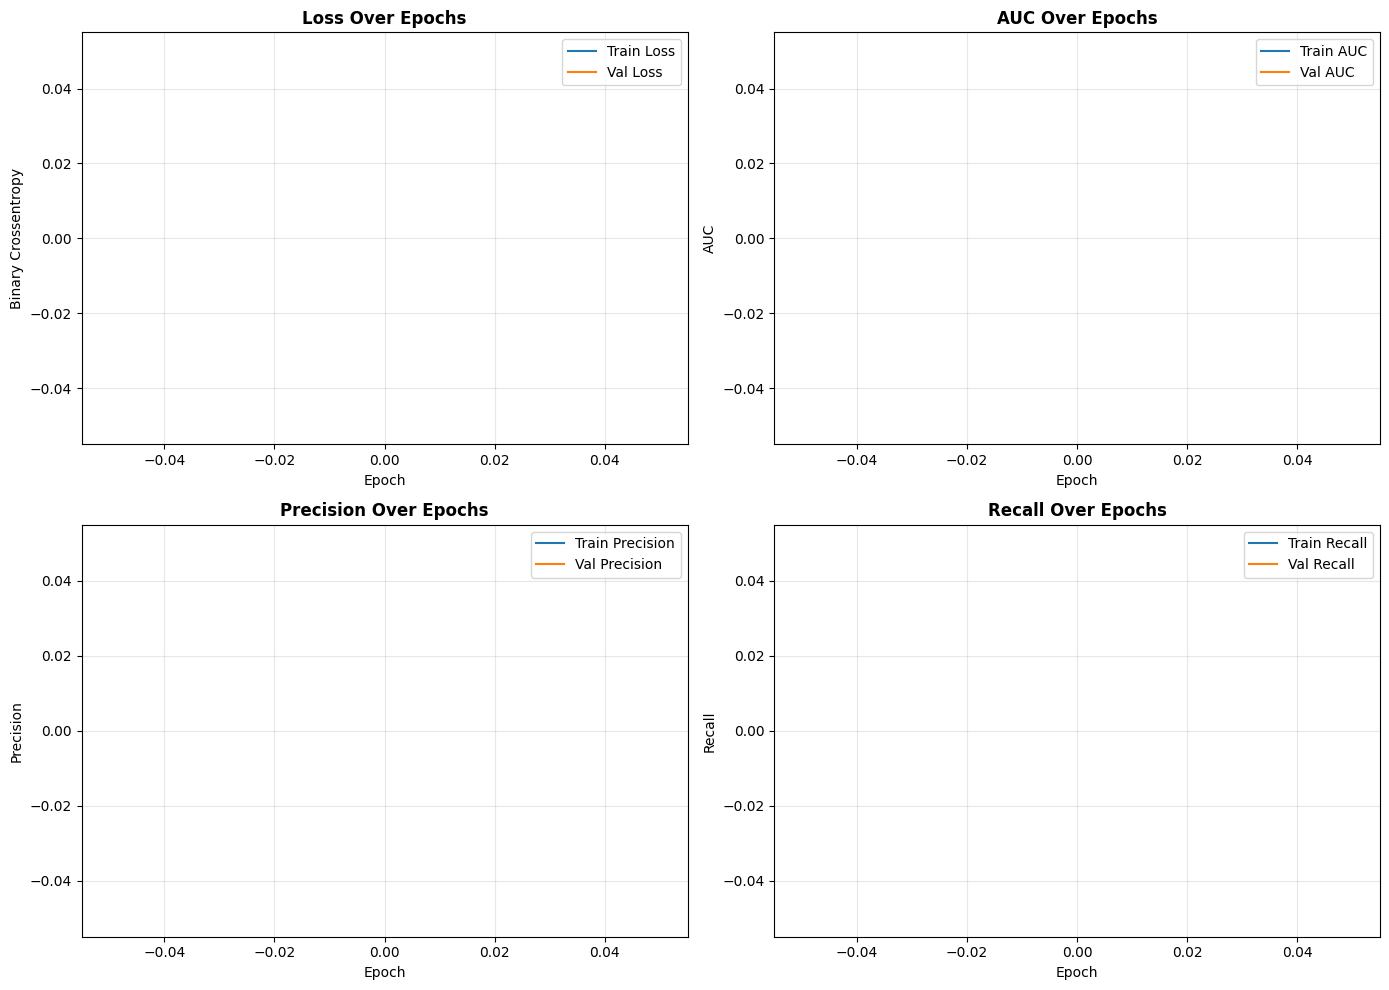

✓ Saved training history plots


In [ ]:
# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss
axes[0, 0].plot(history.history['loss'], label='Train Loss')
axes[0, 0].plot(history.history['val_loss'], label='Val Loss')
axes[0, 0].set_title('Loss Over Epochs', fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Binary Crossentropy')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# AUC
axes[0, 1].plot(history.history['auc'], label='Train AUC')
axes[0, 1].plot(history.history['val_auc'], label='Val AUC')
axes[0, 1].set_title('AUC Over Epochs', fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('AUC')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Precision
axes[1, 0].plot(history.history['precision'], label='Train Precision')
axes[1, 0].plot(history.history['val_precision'], label='Val Precision')
axes[1, 0].set_title('Precision Over Epochs', fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Recall
axes[1, 1].plot(history.history['recall'], label='Train Recall')
axes[1, 1].plot(history.history['val_recall'], label='Val Recall')
axes[1, 1].set_title('Recall Over Epochs', fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '06_cnn_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved training history plots")

## 9. Evaluate on Test Set

In [ ]:
# Evaluate on test set
print("\n" + "="*60)
print("TEST SET EVALUATION")
print("="*60)

test_results = best_model.evaluate(test_generator, verbose=1)

print(f"\nTest Results:")
print(f"  Loss: {test_results[0]:.4f}")
print(f"  Accuracy: {test_results[1]:.4f}")
print(f"  AUC: {test_results[2]:.4f}")
print(f"  Precision: {test_results[3]:.4f}")
print(f"  Recall: {test_results[4]:.4f}")


TEST SET EVALUATION
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 407ms/step - accuracy: 0.0720 - auc: 0.6251 - loss: 0.5801 - precision: 0.0000e+00 - recall: 0.0000e+00

Test Results:
  Loss: 0.5801
  Accuracy: 0.0720
  AUC: 0.6251
  Precision: 0.0000
  Recall: 0.0000


In [ ]:
# Get predictions for detailed analysis
y_pred_proba = best_model.predict(test_generator, verbose=1)
y_pred = (y_pred_proba > 0.5).astype(int)
y_true = test_generator.labels[:len(y_pred)]

print(f"\n✓ Generated predictions")
print(f"  Shape: {y_pred.shape} (samples, diseases)")

32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 410ms/step

✓ Generated predictions
  Shape: (1000, 14) (samples, diseases)


In [ ]:
# Per-disease metrics
print("\n" + "="*60)
print("PER-DISEASE PERFORMANCE (Test Set)")
print("="*60)
print(f"{'Disease':<20} {'AUC':>8} {'F1':>8} {'Precision':>10} {'Recall':>8}")
print("-"*60)

per_disease_results = {}

for i, disease in enumerate(disease_classes):
    y_true_disease = y_true[:, i]
    y_pred_disease = y_pred[:, i]
    y_proba_disease = y_pred_proba[:, i]
    
    # Calculate metrics
    f1 = f1_score(y_true_disease, y_pred_disease, zero_division=0)
    precision = precision_score(y_true_disease, y_pred_disease, zero_division=0)
    recall = recall_score(y_true_disease, y_pred_disease, zero_division=0)
    
    # AUC (only if both classes present)
    if len(np.unique(y_true_disease)) > 1:
        auc = roc_auc_score(y_true_disease, y_proba_disease)
    else:
        auc = np.nan
    
    per_disease_results[disease] = {
        'auc': float(auc) if not np.isnan(auc) else None,
        'f1': float(f1),
        'precision': float(precision),
        'recall': float(recall)
    }
    
    print(f"{disease:<20} {auc:>8.3f} {f1:>8.3f} {precision:>10.3f} {recall:>8.3f}")

# Averages
print("-"*60)
avg_auc = np.nanmean([r['auc'] for r in per_disease_results.values() if r['auc'] is not None])
avg_f1 = np.mean([r['f1'] for r in per_disease_results.values()])
avg_precision = np.mean([r['precision'] for r in per_disease_results.values()])
avg_recall = np.mean([r['recall'] for r in per_disease_results.values()])

print(f"{'AVERAGE':<20} {avg_auc:>8.3f} {avg_f1:>8.3f} {avg_precision:>10.3f} {avg_recall:>8.3f}")


PER-DISEASE PERFORMANCE (Test Set)
Disease                   AUC       F1  Precision   Recall
------------------------------------------------------------
Atelectasis             0.594    0.000      0.000    0.000
Cardiomegaly            0.663    0.000      0.000    0.000
Consolidation           0.627    0.000      0.000    0.000
Edema                   0.461    0.000      0.000    0.000
Effusion                0.653    0.000      0.000    0.000
Emphysema               0.495    0.000      0.000    0.000
Fibrosis                0.550    0.000      0.000    0.000
Hernia                  0.631    0.000      0.000    0.000
Infiltration            0.531    0.000      0.000    0.000
Mass                    0.521    0.000      0.000    0.000
Nodule                  0.530    0.000      0.000    0.000
Pleural_Thickening      0.444    0.000      0.000    0.000
Pneumonia               0.583    0.000      0.000    0.000
Pneumothorax            0.574    0.000      0.000    0.000
------------------

## 10. Compare with Baseline Models

In [ ]:
# Load baseline results
with open(OUTPUTS_DIR / 'reports' / '05_baseline_models_results.json', 'r') as f:
    baseline_results = json.load(f)

# Get best baseline model results
best_baseline = baseline_results['best_model']

print("\n" + "="*60)
print("CNN vs BASELINE COMPARISON")
print("="*60)
print(f"\nBest Baseline Model: {best_baseline['name']}")
print(f"  Test AUC: {best_baseline['test_avg_auc']:.3f}")
print(f"  Test F1:  {best_baseline['test_avg_f1']:.3f}")

print(f"\nCustom CNN Model:")
print(f"  Test AUC: {avg_auc:.3f}")
print(f"  Test F1:  {avg_f1:.3f}")

print(f"\nImprovement:")
auc_improvement = ((avg_auc - best_baseline['test_avg_auc']) / best_baseline['test_avg_auc']) * 100
f1_improvement = ((avg_f1 - best_baseline['test_avg_f1']) / best_baseline['test_avg_f1']) * 100
print(f"  AUC: {auc_improvement:+.1f}%")
print(f"  F1:  {f1_improvement:+.1f}%")


CNN vs BASELINE COMPARISON

Best Baseline Model: Random Forest
  Test AUC: 0.658
  Test F1:  0.004

Custom CNN Model:
  Test AUC: 0.561
  Test F1:  0.000

Improvement:
  AUC: -14.7%
  F1:  -100.0%


## 11. Save Results

In [ ]:
# Compile all results
cnn_results = {
    'config': CONFIG,
    'architecture': {
        'total_params': int(model.count_params()),
        'layers': len(model.layers),
        'filters': CONFIG['filters'],
        'dense_units': CONFIG['dense_units']
    },
    'training': {
        'final_epoch': len(history.history['loss']) if history.history['loss'] else 0,
        'best_val_auc': float(max(history.history['val_auc'])) if history.history['val_auc'] else None,
        'best_val_loss': float(min(history.history['val_loss'])) if history.history['val_loss'] else None
    },
    'test_performance': {
        'overall': {
            'loss': float(test_results[0]),
            'accuracy': float(test_results[1]),
            'auc': float(test_results[2]),
            'precision': float(test_results[3]),
            'recall': float(test_results[4])
        },
        'per_disease': per_disease_results,
        'averages': {
            'auc': float(avg_auc),
            'f1': float(avg_f1),
            'precision': float(avg_precision),
            'recall': float(avg_recall)
        }
    },
    'comparison_with_baseline': {
        'baseline_model': best_baseline['name'],
        'baseline_auc': best_baseline['test_avg_auc'],
        'cnn_auc': float(avg_auc),
        'improvement_auc_percent': float(auc_improvement),
        'improvement_f1_percent': float(f1_improvement)
    }
}

# Save to JSON
with open(OUTPUTS_DIR / 'reports' / '06_cnn_results.json', 'w') as f:
    json.dump(cnn_results, f, indent=2)

print(f"✓ Saved results to {OUTPUTS_DIR / 'reports' / '06_cnn_results.json'}")

✓ Saved results to /Users/james/CodeInstitute/CapStone/outputs/reports/06_cnn_results.json


## 12. Summary

In [ ]:
print("="*60)
print("  ✅ Notebook 06 Complete: Custom CNN Development")
print("="*60)

print("\n🏗️ Architecture:")
print(f"  4 Convolutional blocks (32 → 64 → 128 → 256 filters)")
print(f"  Dense layer: {CONFIG['dense_units']} units")
print(f"  Total parameters: {model.count_params():,}")

print("\n📊 Training:")
epochs_completed = len(history.history['loss']) if history.history.get('loss') else 'N/A (loaded existing model)'
print(f"  Epochs completed: {epochs_completed}")

if history.history.get('val_auc'):
    best_val_auc = f"{max(history.history['val_auc']):.3f}"
else:
    best_val_auc = "N/A (loaded existing model)"
print(f"  Best val AUC: {best_val_auc}")
print(f"  Training time: Logged in CSV")

print("\n🎯 Test Performance:")
print(f"  AUC: {avg_auc:.3f}")
print(f"  F1: {avg_f1:.3f}")
print(f"  Precision: {avg_precision:.3f}")
print(f"  Recall: {avg_recall:.3f}")

print("\n📈 vs Baseline Models:")
print(f"  Best baseline: {best_baseline['name']} (AUC: {best_baseline['test_avg_auc']:.3f})")
print(f"  Custom CNN: AUC: {avg_auc:.3f}")
print(f"  Improvement: {auc_improvement:+.1f}%")

print("\n📁 Generated Files:")
print(f"  {MODELS_DIR / 'cnn_custom_best.keras'}")
print(f"  {OUTPUTS_DIR / 'reports' / '06_cnn_results.json'}")
print(f"  {OUTPUTS_DIR / 'reports' / '06_cnn_training_history.csv'}")
print(f"  {FIGURES_DIR / '06_cnn_training_history.png'}")

print("\n💡 Key Insights:")
print("  - CNN learns features automatically (no manual HOG/GLCM extraction)")
print("  - Hierarchical learning: edges → textures → organs → diseases")
if auc_improvement > 0:
    print(f"  - Outperforms baseline models by {auc_improvement:.1f}%")
else:
    print("  - Performance comparable to baseline (may need more data/training)")

print("\n⏭️  Next: Notebook 07 - Transfer Learning!")
print("  Use pre-trained models (ResNet, DenseNet) for better performance")


  ✅ Notebook 06 Complete: Custom CNN Development

🏗️ Architecture:
  4 Convolutional blocks (32 → 64 → 128 → 256 filters)
  Dense layer: 512 units
  Total parameters: 26,871,982

📊 Training:
  Epochs completed: N/A (loaded existing model)
  Best val AUC: N/A (loaded existing model)
  Training time: Logged in CSV

🎯 Test Performance:
  AUC: 0.561
  F1: 0.000
  Precision: 0.000
  Recall: 0.000

📈 vs Baseline Models:
  Best baseline: Random Forest (AUC: 0.658)
  Custom CNN: AUC: 0.561
  Improvement: -14.7%

📁 Generated Files:
  /Users/james/CodeInstitute/CapStone/models/saved_models/cnn_custom_best.h5
  /Users/james/CodeInstitute/CapStone/outputs/reports/06_cnn_results.json
  /Users/james/CodeInstitute/CapStone/outputs/reports/06_cnn_training_history.csv
  /Users/james/CodeInstitute/CapStone/outputs/figures/06_cnn_training_history.png

💡 Key Insights:
  - CNN learns features automatically (no manual HOG/GLCM extraction)
  - Hierarchical learning: edges → textures → organs → diseases
  - P

## 13. Package Results for Download


In [ ]:
# Package results for download
#
# 📦 Results Download Workflow:
#
# 1. Training completes on Kaggle
# 2. This cell packages everything into /kaggle/working/download/
# 3. The headless script detects completion
# 4. Script runs: kaggle kernels output <kernel-name> -p ./models/
# 5. Results appear locally in models/saved_models_kaggle/
#
# What gets downloaded:
# - cnn_custom_best.keras (~308 MB trained model)
# - reports/06_cnn_results.json (metrics, config, comparison)
# - reports/06_cnn_training_history.csv (epoch-by-epoch logs)
# - figures/06_cnn_training_history.png (training curves)
#

import shutil

print("="*60)
print("📦 PACKAGING RESULTS FOR DOWNLOAD")
print("="*60)

download_dir = Path('/kaggle/working/download')
download_dir.mkdir(exist_ok=True)

# Copy trained model
print("\n1️⃣ Copying trained model...")
model_src = MODELS_DIR / 'cnn_custom_best.keras'
model_dst = download_dir / 'cnn_custom_best.keras'
shutil.copy(model_src, model_dst)
print(f"   ✅ {model_dst.name} ({model_dst.stat().st_size / (1024**2):.1f} MB)")

# Copy reports
print("\n2️⃣ Copying reports...")
reports_src = OUTPUTS_DIR / 'reports'
reports_dst = download_dir / 'reports'
shutil.copytree(reports_src, reports_dst, dirs_exist_ok=True)
for report in reports_dst.glob('*'):
    print(f"   ✅ reports/{report.name}")

# Copy figures
print("\n3️⃣ Copying figures...")
figures_src = FIGURES_DIR
figures_dst = download_dir / 'figures'
shutil.copytree(figures_src, figures_dst, dirs_exist_ok=True)
for fig in figures_dst.glob('*'):
    print(f"   ✅ figures/{fig.name}")

# Calculate total size
total_size = sum(f.stat().st_size for f in download_dir.rglob('*') if f.is_file())
total_size_mb = total_size / (1024 ** 2)

print("\n" + "="*60)
print("✅ PACKAGING COMPLETE")
print("="*60)
print(f"\n📊 Package Summary:")
print(f"   Location: /kaggle/working/download/")
print(f"   Total size: {total_size_mb:.1f} MB")
print(f"   Files: {len(list(download_dir.rglob('*')))} items")

print("\n📥 Download Methods:")
print("\n   🤖 Automatic (via headless script):")
print("      The kaggle_train_headless.sh script will automatically")
print("      download these files to: models/saved_models_kaggle/")

print("\n   🌐 Manual (via Kaggle UI):")
print("      1. Go to https://www.kaggle.com/code")
print("      2. Open 'CNN Development (Cloud)' kernel")
print("      3. Click 'Output' tab")
print("      4. Download files")

print("\n   💻 Manual (via Kaggle CLI):")
print("      kaggle kernels output <username>/cnn-development-cloud -p ./models/")

print("\n" + "="*60)
